In [12]:
"""
=============================================================================
NFHS-5 District-Level Maternal Health Analysis — Starter Script
=============================================================================
Author: Kaushal Kumar
Project: District-Level Disparities in Maternal Healthcare Access Across India

This script:
  1. Downloads NFHS-5 district factsheet data from GitHub
  2. Selects maternal health indicators
  3. Cleans and prepares the dataset
  4. Produces descriptive statistics
  5. Creates initial choropleth maps

Requirements:
  pip install pandas numpy matplotlib geopandas requests openpyxl
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import subprocess
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 1: LOAD NFHS-5 DISTRICT FACTSHEET DATA
# ============================================================================

print("=" * 70)
print("STEP 1: Loading NFHS-5 District Factsheet Data")
print("=" * 70)

subprocess.check_call([sys.executable, "-m", "pip", "install", "xlrd>=2.0.1"])

df_raw = pd.read_excel("../Data/NFHS 5 district wise data/ssrn datasheet.xls", engine="xlrd")
print(f"Loaded from local data: {df_raw.shape[0]} districts, {df_raw.shape[1]} indicators")

# Quick look at the data
if not df_raw.empty:
    print(f"\nColumns ({len(df_raw.columns)}):")
    for i, col in enumerate(df_raw.columns):
        print(f"  {i:3d}. {col}")

STEP 1: Loading NFHS-5 District Factsheet Data
Loaded from local data: 707 districts, 109 indicators

Columns (109):
    0. District Names
    1. State/UT
    2. Number of Households surveyed
    3. Number of Women age 15-49 years interviewed
    4. Number of Men age 15-54 years interviewed
    5. Female population age 6 years and above who ever attended school (%)
    6. Population below age 15 years (%)
    7.  Sex ratio of the total population (females per 1,000 males)
    8. Sex ratio at birth for children born in the last five years (females per 1,000 males)
    9. Children under age 5 years whose birth was registered with the civil authority (%)
   10. Deaths in the last 3 years registered with the civil authority (%)
   11. Population living in households with electricity (%)
   12. Population living in households with an improved drinking-water source1 (%)
   13. Population living in households that use an improved sanitation facility2 (%)
   14. Households using clean fuel for

In [13]:
df_raw.head()

,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ≥160 mm of Hg and/or Diastolic ≥100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ≥140 mm of Hg and/or Diastolic ≥90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,Nicobars,Andaman & Nicobar Islands,882,764,125,78.01,22.98,973.31,927.41,98.01,...,32.86,11.06,46.97,13.35,13.16,5.37,63.46,76.79,29.59,64.49
1,North & Middle Andaman,Andaman & Nicobar Islands,874,789,108,82.66,19.82,949.82,844.43,100.00,...,22.62,5.97,32.20,1.70,0.25,15.84,46.77,70.47,5.08,45.26
2,South Andaman,Andaman & Nicobar Islands,868,844,134,84.68,20.95,967.48,934.92,96.53,...,17.88,6.09,26.90,1.32,0.67,8.00,19.60,50.76,1.72,32.81
3,Srikakulam,Andhra Pradesh,874,780,100,59.99,20.71,1139.51,1162.58,94.96,...,14.37,5.51,22.89,1.04,0.23,3.76,7.09,21.32,0.55,28.26
4,Vizianagaram,Andhra Pradesh,902,853,134,55.95,20.56,1114.35,898.03,95.42,...,14.83,6.43,25.13,4.90,0.63,7.33,11.41,21.47,0.80,32.30


In [17]:
# Rename columns
df = df_raw.rename(columns={
    'District Names': 'District',
    'State/UT': 'State',
    df_raw.columns[18]: 'female_literacy',
    df_raw.columns[20]: 'child_marriage',
    df_raw.columns[14]: 'clean_fuel',
    df_raw.columns[16]: 'health_insurance',
    df_raw.columns[13]: 'improved_sanitation',
    df_raw.columns[11]: 'hh_electricity',
    df_raw.columns[36]: 'anc_first_trimester',
    df_raw.columns[37]: 'anc_4plus_visits',
    df_raw.columns[42]: 'postnatal_care_2days',
    df_raw.columns[46]: 'institutional_births',
    df_raw.columns[47]: 'institutional_births_public',
    df_raw.columns[49]: 'skilled_birth_attendance',
    df_raw.columns[50]: 'csection_rate',
    df_raw.columns[77]: 'child_stunting',
    df_raw.columns[80]: 'child_underweight',
    df_raw.columns[88]: 'women_anaemic',
})

# Convert to numeric (* means missing)
num_cols = ['female_literacy', 'child_marriage', 'clean_fuel', 'health_insurance',
            'improved_sanitation', 'institutional_births', 'anc_4plus_visits',
            'postnatal_care_2days', 'skilled_birth_attendance', 'csection_rate',
            'child_stunting', 'women_anaemic']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Total districts: {len(df)}")
print(f"States: {df['State'].nunique()}")
print(f"Districts with institutional_births: {df['institutional_births'].notna().sum()}")

Total districts: 707
States: State    36
State     0
dtype: int64
Districts with institutional_births: 707


In [18]:
df.head()

,District,State,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%),ind_num,NFHS-5,State,State-Code,District
0,Nicobars,Andaman & Nicobar Islands,882,764,125,78.01,22.98,973.31,927.41,98.01,...,5.37,63.46,76.79,29.59,64.49,<NA>,NaN,NaN,NaN,NaN
1,North & Middle Andaman,Andaman & Nicobar Islands,874,789,108,82.66,19.82,949.82,844.43,100.00,...,15.84,46.77,70.47,5.08,45.26,<NA>,NaN,NaN,NaN,NaN
2,South Andaman,Andaman & Nicobar Islands,868,844,134,84.68,20.95,967.48,934.92,96.53,...,8.00,19.60,50.76,1.72,32.81,<NA>,NaN,NaN,NaN,NaN
3,Srikakulam,Andhra Pradesh,874,780,100,59.99,20.71,1139.51,1162.58,94.96,...,3.76,7.09,21.32,0.55,28.26,<NA>,NaN,NaN,NaN,NaN
4,Vizianagaram,Andhra Pradesh,902,853,134,55.95,20.56,1114.35,898.03,95.42,...,7.33,11.41,21.47,0.80,32.30,<NA>,NaN,NaN,NaN,NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707 entries, 0 to 706
Columns: 114 entries, District to District
dtypes: Int64(1), float64(75), int64(3), object(35)
memory usage: 630.5+ KB


In [20]:
df.isnull().sum()

District                                         0
State                                            0
Number of Households surveyed                    0
Number of Women age 15-49 years interviewed      0
Number of Men age 15-54 years interviewed        0
                                              ... 
ind_num                                        707
NFHS-5                                         707
State                                          707
State-Code                                     707
District                                       707
Length: 114, dtype: int64

In [22]:
keep_cols = ['District', 'State',
             'institutional_births', 'anc_4plus_visits', 
             'skilled_birth_attendance', 'postnatal_care_2days',
             'female_literacy', 'child_marriage', 'health_insurance',
             'clean_fuel', 'improved_sanitation', 'hh_electricity',
             'csection_rate', 'women_anaemic', 'child_stunting',
             'child_underweight', 'anc_first_trimester',
             'institutional_births_public']

df_analysis = df[keep_cols].copy()
df_analysis.to_csv("nfhs5_analysis_ready.csv", index=False)
print(f"Final dataset: {df_analysis.shape}")

Final dataset: (707, 20)


In [24]:
# Fix duplicate 'State' columns
if isinstance(df_analysis['State'], pd.DataFrame):
    df_analysis = df_analysis.loc[:, ~df_analysis.columns.duplicated()]
    print(f"Removed duplicate columns. Shape now: {df_analysis.shape}")

Removed duplicate columns. Shape now: (707, 18)


In [25]:
# ============================================================================
# STEP 4: DESCRIPTIVE STATISTICS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: Descriptive Statistics")
print("=" * 70)

# Define variable groups
dep_vars = ['institutional_births', 'anc_4plus_visits', 'skilled_birth_attendance', 'postnatal_care_2days']
indep_vars = ['female_literacy', 'child_marriage', 'health_insurance', 'clean_fuel', 'improved_sanitation', 'hh_electricity']
context_vars = ['csection_rate', 'women_anaemic', 'child_stunting', 'child_underweight']

# Summary statistics
print("\n--- Dependent Variables ---")
print(df_analysis[dep_vars].describe().round(2).to_string())

print("\n--- Independent Variables ---")
print(df_analysis[indep_vars].describe().round(2).to_string())

# State-level aggregation
state_means = df_analysis.groupby('State')[dep_vars + indep_vars].mean().round(2)
print(f"\n--- State-wise Means (key indicators) ---")
print(state_means[['institutional_births', 'female_literacy', 'child_marriage']].to_string())
state_means.to_csv('nfhs5_maternal_state_means.csv')
print("\nSaved: nfhs5_maternal_state_means.csv")

# Bottom 20 districts
print(f"\n--- Bottom 20 Districts by Institutional Delivery Rate ---")
bottom_20 = df_analysis.nsmallest(20, 'institutional_births')[['State', 'District', 'institutional_births', 'female_literacy', 'child_marriage']].reset_index(drop=True)
bottom_20.index = bottom_20.index + 1
print(bottom_20.to_string())

# Top 20 districts
print(f"\n--- Top 20 Districts by Institutional Delivery Rate ---")
top_20 = df_analysis.nlargest(20, 'institutional_births')[['State', 'District', 'institutional_births', 'female_literacy', 'child_marriage']].reset_index(drop=True)
top_20.index = top_20.index + 1
print(top_20.to_string())

# Correlation matrix
print(f"\n--- Correlation with Institutional Births ---")
corr = df_analysis[dep_vars + indep_vars].corr()['institutional_births'].drop('institutional_births').sort_values(ascending=False)
print(corr.round(3).to_string())


STEP 4: Descriptive Statistics

--- Dependent Variables ---
       institutional_births  anc_4plus_visits  skilled_birth_attendance  postnatal_care_2days
count                707.00            707.00                    707.00                707.00
mean                  88.67             60.33                     89.57                 78.70
std                   12.00             20.77                      9.92                 15.96
min                   21.40            -60.39                     30.94                -97.48
25%                   83.68             45.02                     84.88                 71.25
50%                   92.20             62.47                     92.28                 83.06
75%                   97.40             76.02                     96.94                 89.97
max                  100.00             98.65                    100.00                 99.49

--- Independent Variables ---
       female_literacy  child_marriage  health_insurance  clea

In [26]:
top_20

,State,District,institutional_births,female_literacy,child_marriage
1,Goa,South Goa,100.0,93.76,3.90
2,Gujarat,Porbandar,100.0,84.33,9.96
3,Karnataka,Tumkur,100.0,81.87,24.80
4,Karnataka,Hassan,100.0,82.04,16.15
5,Karnataka,Dakshina Kannada,100.0,92.72,4.89
6,Karnataka,Mysore,100.0,78.92,17.50
7,Karnataka,Chamarajanagar,100.0,72.36,19.29
8,Karnataka,Bangalore Rural,100.0,83.81,14.11
9,Karnataka,Ramanagara,100.0,82.67,11.81
10,Kerala,Kasaragod,100.0,95.91,4.74



STEP 5: Visualizations
Saved: 01_indicator_distributions.png


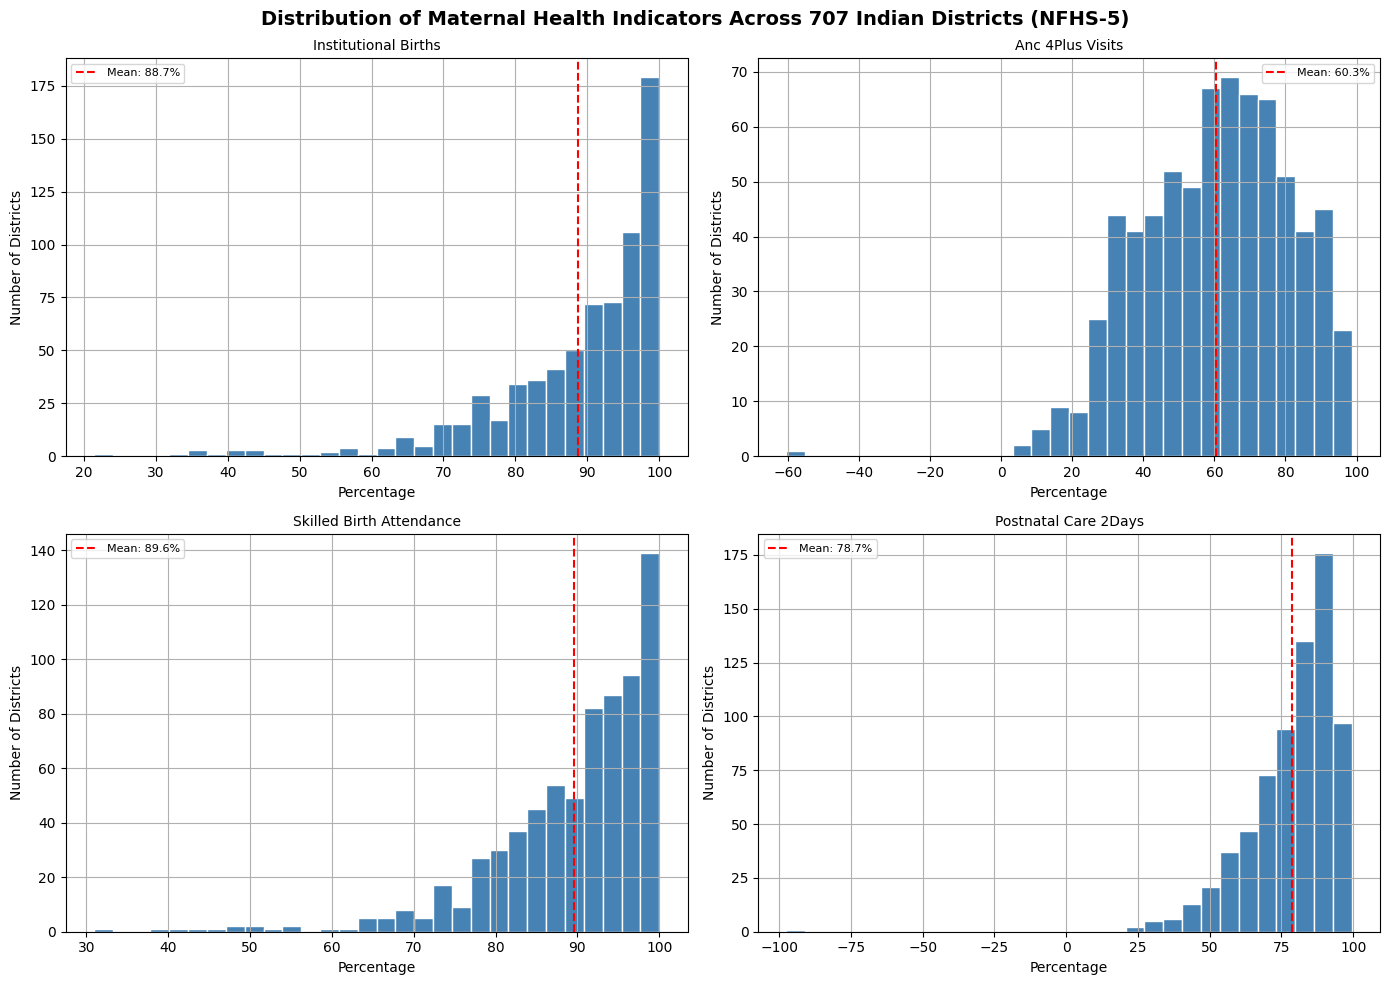

Saved: 02_state_comparison.png


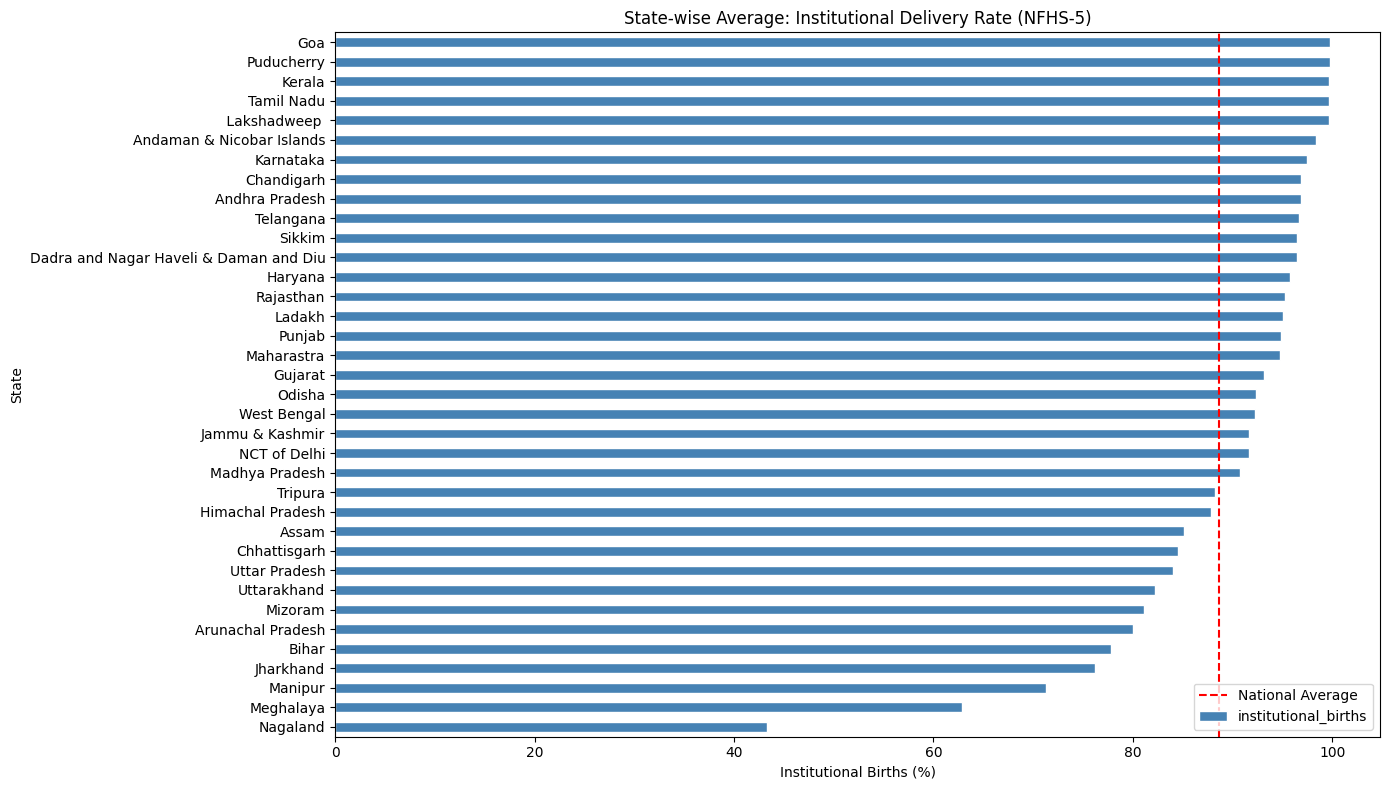

Saved: 03_correlation_matrix.png


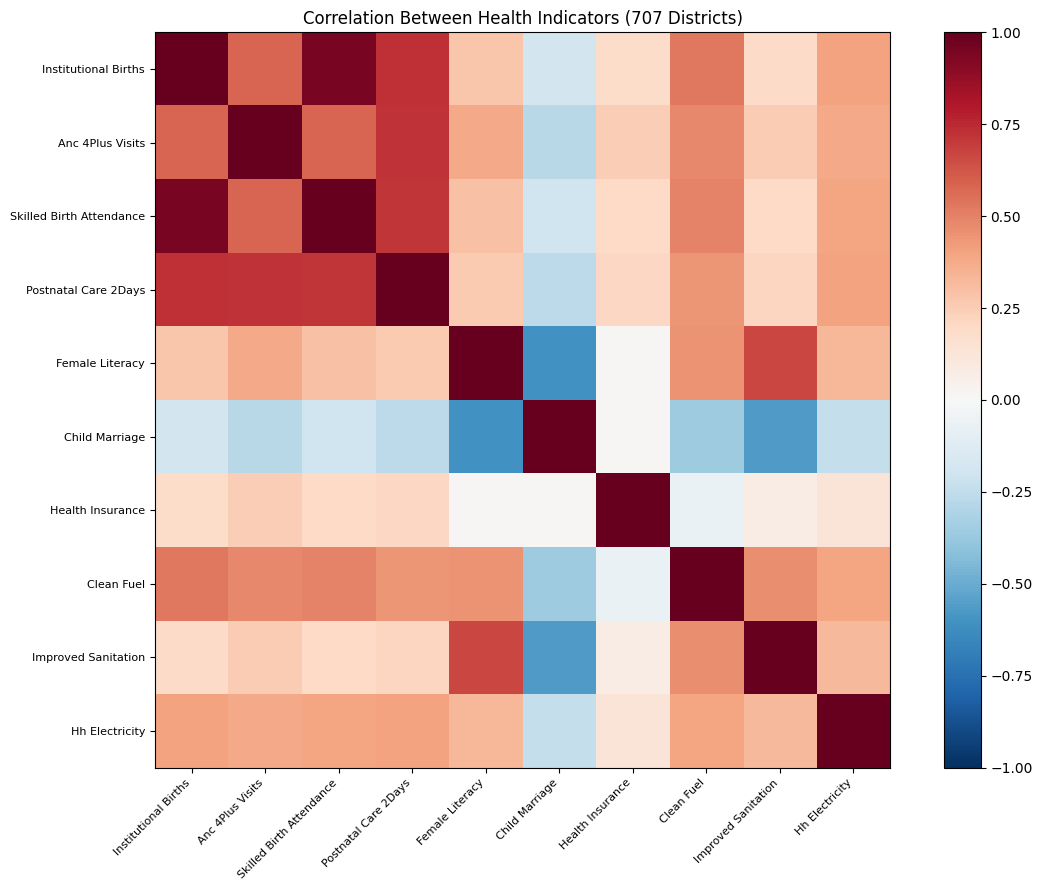

Saved: 04_scatter_literacy_vs_delivery.png


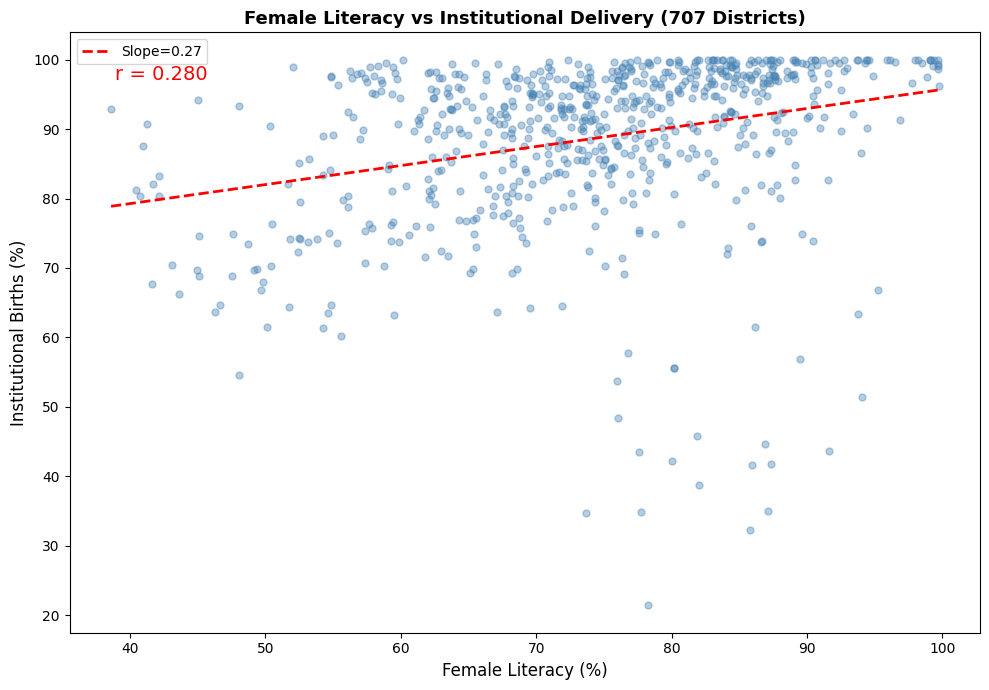


DONE — All 4 visualizations saved.


In [28]:
# ============================================================================
# STEP 5: INITIAL VISUALIZATIONS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 5: Visualizations")
print("=" * 70)

dep_vars = ['institutional_births', 'anc_4plus_visits', 'skilled_birth_attendance', 'postnatal_care_2days']
indep_vars = ['female_literacy', 'child_marriage', 'health_insurance', 'clean_fuel', 'improved_sanitation', 'hh_electricity']
all_vars = dep_vars + indep_vars

# --- 5a: Distribution of key indicators ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Maternal Health Indicators Across 707 Indian Districts (NFHS-5)',
             fontsize=14, fontweight='bold')

for i, col in enumerate(dep_vars):
    ax = axes[i // 2, i % 2]
    df_analysis[col].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Percentage')
    ax.set_ylabel('Number of Districts')
    ax.axvline(df_analysis[col].mean(), color='red', linestyle='--',
               label=f'Mean: {df_analysis[col].mean():.1f}%')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('01_indicator_distributions.png', dpi=150, bbox_inches='tight')
print("Saved: 01_indicator_distributions.png")
plt.show()

# --- 5b: State-level bar chart ---
fig, ax = plt.subplots(figsize=(14, 8))
state_avg = df_analysis.groupby('State')['institutional_births'].mean().sort_values()
state_avg.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Institutional Births (%)')
ax.set_title('State-wise Average: Institutional Delivery Rate (NFHS-5)')
ax.axvline(df_analysis['institutional_births'].mean(), color='red', linestyle='--', label='National Average')
ax.legend()
plt.tight_layout()
plt.savefig('02_state_comparison.png', dpi=150, bbox_inches='tight')
print("Saved: 02_state_comparison.png")
plt.show()

# --- 5c: Correlation matrix ---
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_analysis[all_vars].corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
labels = [c.replace('_', ' ').title() for c in all_vars]
ax.set_xticks(range(len(all_vars)))
ax.set_yticks(range(len(all_vars)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title('Correlation Between Health Indicators (707 Districts)')
plt.tight_layout()
plt.savefig('03_correlation_matrix.png', dpi=150, bbox_inches='tight')
print("Saved: 03_correlation_matrix.png")
plt.show()

# --- 5d: Scatter — Female Literacy vs Institutional Births ---
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df_analysis['female_literacy'], df_analysis['institutional_births'],
           alpha=0.4, s=25, color='steelblue')
mask = df_analysis[['female_literacy', 'institutional_births']].dropna().index
z = np.polyfit(df_analysis.loc[mask, 'female_literacy'],
               df_analysis.loc[mask, 'institutional_births'], 1)
x_range = np.linspace(df_analysis['female_literacy'].min(), df_analysis['female_literacy'].max(), 100)
ax.plot(x_range, np.poly1d(z)(x_range), 'r--', lw=2, label=f'Slope={z[0]:.2f}')
r = df_analysis[['female_literacy', 'institutional_births']].corr().iloc[0, 1]
ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=14, color='red')
ax.set_xlabel('Female Literacy (%)', fontsize=12)
ax.set_ylabel('Institutional Births (%)', fontsize=12)
ax.set_title('Female Literacy vs Institutional Delivery (707 Districts)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('04_scatter_literacy_vs_delivery.png', dpi=150, bbox_inches='tight')
print("Saved: 04_scatter_literacy_vs_delivery.png")
plt.show()

print("\nDONE — All 4 visualizations saved.")

In [1]:
import os
import urllib.request

# Create folder
folder = "india_district_shapefile"
os.makedirs(folder, exist_ok=True)

# All 6 shapefile components
base_url = "https://raw.githubusercontent.com/datameet/maps/master/Districts/Census_2011/"
files = [
    "2011_Dist.shp",
    "2011_Dist.shx",
    "2011_Dist.dbf",
    "2011_Dist.prj",
    "2011_Dist.sbn",
    "2011_Dist.sbx",
]

for f in files:
    url = base_url + f
    path = os.path.join(folder, f)
    print(f"Downloading {f}...", end=" ")
    urllib.request.urlretrieve(url, path)
    print(f"Done ({os.path.getsize(path):,} bytes)")

print(f"\nAll files saved to '{folder}/'")


All files saved to 'india_district_shapefile/'


In [30]:
df_analysis.shape

(707, 18)

In [32]:
df_analysis.to_csv("../Data/analysis_ready.csv", index=False)